# Population 中的异质突触

这个例子使用一个真实的多室 HH cell，说明同一个 population 中的不同 cell 如何拥有不同数量、不同位置的突触。

我们分别演示两种入口：

1. 先用 `post[i].place(...)` 显式放置突触，再建立连接；
2. post cell 不预先放置突触，由 network projection 自动创建异质突触池。

In [1]:
import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import braincell
from braincell import mech
from braincell.filter import AllRegion, at, branch_in

# 这个例子显式使用 64 位，覆盖多室 CV 在相邻时间步过阈值的情况。
brainstate.environ.set(precision=64)

## 1. 构建真实的 soma + 2 dend HH cell

每个 cell 都包含 sodium、potassium 和 leak channel，并使用正常的 `solver="staggered"`。所有 population 成员共享相同的 morphology 和膜机制。

In [2]:
def build_morphology():
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[120.0] * u.um,
        radii=[2.0, 1.0] * u.um,
        type="basal_dendrite",
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[180.0] * u.um,
        radii=[2.5, 0.8] * u.um,
        type="basal_dendrite",
    )

    tree = braincell.Morphology.from_root(soma, name="soma")
    tree.soma.dend_a = dend_a
    tree.soma.dend_b = dend_b
    return tree


def add_hh_membrane(cell):
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * (u.uF / u.cm**2),
            axial_resistivity=100.0 * (u.ohm * u.cm),
        ),
        mech.Ion("SodiumFixed", E=50.0 * u.mV),
        mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        mech.Channel("Na_HH1952", g_max=120.0 * (u.mS / u.cm**2)),
        mech.Channel("K_HH1952", g_max=36.0 * (u.mS / u.cm**2)),
        mech.Channel("IL", g_max=0.3 * (u.mS / u.cm**2), E=-54.387 * u.mV),
    )

In [3]:
def build_population(name, *, presynaptic=False):
    cell = braincell.Cell(
        build_morphology(),
        cv_policy=braincell.CVPerBranch(),
        pop_size=(4,),
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        solver="staggered",
        name=name,
    )
    add_hh_membrane(cell)

    # 原有 place 接口保持广播语义：四个 cell 都在 soma 记录电压。
    cell.place(at("soma", 0.5), mech.StateProbe(name="v", field="v"))

    if presynaptic:
        # 四个 cell 接受略微错开的正常电流刺激，通过 HH 动力学产生 spike。
        cell.place(
            at("soma", 0.5),
            mech.CurrentClamp(
                delay=u.Quantity(np.asarray([5.0, 5.2, 5.4, 5.6]), u.ms),
                durations=0.2 * u.ms,
                amplitudes=2.0 * u.nA,
            ),
        )
    return cell


def exp_synapse(name="exp"):
    return mech.Synapse(
        "ExpSyn",
        tau=2.0 * u.ms,
        e=0.0 * u.mV,
        weight=1.0 * u.uS,
        name=name,
    )

## 2. 方法一：显式放置异质突触

`post.place(...)` 会把相同位置广播给所有 population 成员。要表达异质性，先选中 cell，再继续使用原来的 `place`：`post[i].place(...)`。

下面四个 post cell 分别拥有 `[1, 2, 1, 3]` 个突触。每一行代码就是一个独立突触实例。

In [4]:
pre_explicit = build_population("pre_explicit", presynaptic=True)
post_explicit = build_population("post_explicit")
exp = exp_synapse()

post_explicit[0].place(at("soma", 0.50), exp)
post_explicit[1].place(at("dend_a", 0.25), exp)
post_explicit[1].place(at("dend_b", 0.75), exp)
post_explicit[2].place(at("dend_a", 0.50), exp)
post_explicit[3].place(at("dend_a", 0.30), exp)
post_explicit[3].place(at("dend_b", 0.50), exp)
post_explicit[3].place(at("dend_b", 0.80), exp)

CellSelection(cell=Cell(root='soma', n_branches=3, n_paint_rules=6, n_place_rules=8, initialized=False), population_indices=(3,))

In [5]:
explicit_instances = [
    {
        "synapse_index": synapse_index,
        "post_index": placement.population_index,
        "branch": placement.branch_name,
        "x": placement.branch_x,
        "cv_id": placement.cv_id,
    }
    for synapse_index, placement in enumerate(
        p for p in post_explicit.point_placements
        if isinstance(p.mechanism, mech.Synapse) and p.mechanism.instance_name == "exp"
    )
]
explicit_instance_table = pd.DataFrame(explicit_instances)
explicit_instance_table

,synapse_index,post_index,branch,x,cv_id
0,0,0,soma,0.50,0
1,1,1,dend_a,0.25,1
2,2,1,dend_b,0.75,2
3,3,2,dend_a,0.50,1
4,4,3,dend_a,0.30,1
5,5,3,dend_b,0.50,2
6,6,3,dend_b,0.80,2


In [6]:
explicit_net = braincell.Network(name="explicit_heterogeneous")
explicit_net.add_population("pre", pre_explicit)
explicit_net.add_population("post", post_explicit)
explicit_edges = explicit_net.add_edges(
    name="pre_to_post",
    pre="pre",
    post="post",
    method=braincell.network.all_pairs(),
)
explicit_net.add_projection(
    name="exp_projection",
    edges="pre_to_post",
    synapse="exp",
    method=braincell.network.per_edge(number=1, replace=True, seed=1),
    source=at("soma", 0.5),
    weight=0.03 * u.uS,
    delay=1.0 * u.ms,
)
explicit_net.build()

explicit_connection = explicit_net.projection_connections["exp_projection"][0]
explicit_contacts = pd.DataFrame({
    "pre_index": explicit_connection.pre_index,
    "post_index": explicit_connection.post_index,
    "synapse_index": explicit_connection.synapse_index,
    "target_owner": explicit_instance_table.loc[
        explicit_connection.synapse_index, "post_index"
    ].to_numpy(),
})
explicit_contacts

,pre_index,post_index,synapse_index,target_owner
0,0,0,0,0
1,0,1,1,1
2,0,2,3,2
3,0,3,5,3
4,1,0,0,0
5,1,1,2,1
6,1,2,3,2
7,1,3,6,3
8,2,0,0,0
9,2,1,1,1


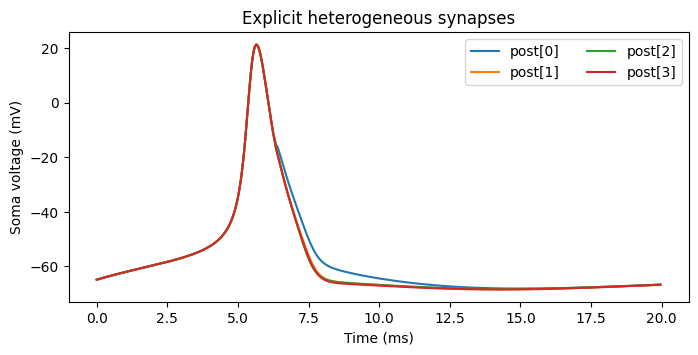

per-CV threshold crossings: [[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, 1.0]]
pre spike counts at source soma(0.5): [1.0, 1.0, 1.0, 1.0]
synapse counts per post: [1, 2, 1, 3]


In [7]:
explicit_result = explicit_net.run(
    dt=0.05 * u.ms,
    duration=20.0 * u.ms,
    spike_recording="full",
)

explicit_full_spikes = np.asarray(explicit_result.spikes["pre"])
explicit_cv_spike_counts = explicit_full_spikes.sum(axis=0)
explicit_spike_counts = explicit_full_spikes[..., 0].sum(axis=0)
explicit_voltage = np.asarray(explicit_result.traces["post"]["v"].to_decimal(u.mV))
np.testing.assert_array_equal(explicit_spike_counts, [1, 1, 1, 1])
np.testing.assert_array_equal(explicit_contacts.post_index, explicit_contacts.target_owner)
assert np.isfinite(explicit_voltage).all()

fig, ax = plt.subplots(figsize=(8, 3.5))
time_ms = np.asarray(explicit_result.time.to_decimal(u.ms))
for post_index in range(4):
    ax.plot(time_ms, explicit_voltage[:, post_index], label=f"post[{post_index}]")
ax.set(xlabel="Time (ms)", ylabel="Soma voltage (mV)", title="Explicit heterogeneous synapses")
ax.legend(ncol=2)
plt.show()

print("per-CV threshold crossings:", explicit_cv_spike_counts.tolist())
print("pre spike counts at source soma(0.5):", explicit_spike_counts.tolist())
print("synapse counts per post:", explicit_instance_table.groupby("post_index").size().tolist())

## 3. 方法二：由 network 自动创建异质突触池

这里的 post population 在创建时没有任何 `ExpSyn`。projection 中直接传入突触声明和 `synapse_pool(...)`：

- `number=[1, 2, 1, 3]` 决定每个 post cell 创建多少个实例；
- `random_locations(...)` 决定这些实例在 dendrite 上的位置；
- `per_edge(...)` 再决定每条 edge 引用哪个属于该 post cell 的实例。

In [8]:
pre_auto = build_population("pre_auto", presynaptic=True)
post_auto = build_population("post_auto")

auto_net = braincell.Network(name="automatic_heterogeneous")
auto_net.add_population("pre", pre_auto)
auto_net.add_population("post", post_auto)
auto_edges = auto_net.add_edges(
    name="pre_to_post",
    pre="pre",
    post="post",
    method=braincell.network.all_pairs(),
)
auto_net.add_projection(
    name="exp_projection",
    edges="pre_to_post",
    synapse=exp_synapse(),
    pool=braincell.network.synapse_pool(
        number=np.asarray([1, 2, 1, 3]),
        placement=braincell.network.random_locations(
            region=branch_in("type", ["basal_dendrite"]),
            seed=7,
        ),
    ),
    method=braincell.network.per_edge(number=1, replace=True, seed=8),
    weight=0.03 * u.uS,
    delay=1.0 * u.ms,
)
auto_net.build()

Network(name='automatic_heterogeneous', populations=2, edge_sets=1, projections=1, connections=0)

In [9]:
auto_instances = pd.DataFrame(
    auto_net.synapse_instance_tables["exp_projection"].rows()
)["synapse_index post_index branch_id branch_x cv_id".split()]
auto_instances

,synapse_index,post_index,branch_id,branch_x,cv_id
0,0,0,2,0.897214,2
1,1,1,2,0.300166,2
2,2,1,1,0.873553,1
3,3,2,1,0.821228,1
4,4,3,2,0.278426,2
5,5,3,2,0.254870,2
6,6,3,1,0.445076,1


In [10]:
auto_connection = auto_net.projection_connections["exp_projection"][0]
auto_contacts = pd.DataFrame({
    "pre_index": auto_connection.pre_index,
    "post_index": auto_connection.post_index,
    "synapse_index": auto_connection.synapse_index,
    "target_owner": auto_instances.loc[
        auto_connection.synapse_index, "post_index"
    ].to_numpy(),
})
np.testing.assert_array_equal(auto_contacts.post_index, auto_contacts.target_owner)
auto_contacts

,pre_index,post_index,synapse_index,target_owner
0,0,0,0,0
1,0,1,2,1
2,0,2,3,2
3,0,3,4,3
4,1,0,0,0
5,1,1,1,1
6,1,2,3,2
7,1,3,6,3
8,2,0,0,0
9,2,1,1,1


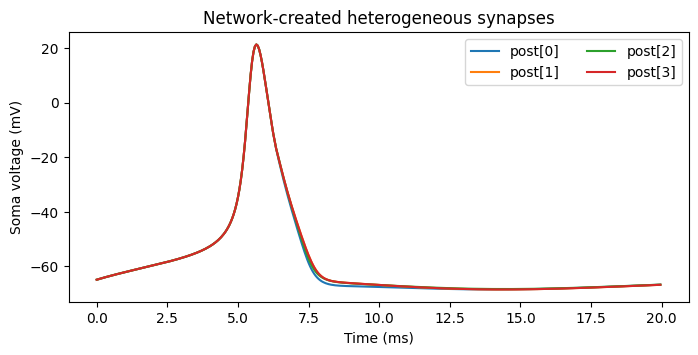

pre spike counts: [1.0, 1.0, 1.0, 1.0]
synapse counts per post: [1, 2, 1, 3]


In [11]:
auto_result = auto_net.run(
    dt=0.05 * u.ms,
    duration=20.0 * u.ms,
    spike_recording="population",
)

auto_spike_counts = np.asarray(auto_result.spikes["pre"]).reshape(len(auto_result.time), -1).sum(axis=0)
auto_voltage = np.asarray(auto_result.traces["post"]["v"].to_decimal(u.mV))
np.testing.assert_array_equal(auto_spike_counts, [1, 1, 1, 1])
assert len(auto_instances) == 7
assert len(auto_contacts) == len(auto_edges.pre_index) == 16
assert np.isfinite(auto_voltage).all()

fig, ax = plt.subplots(figsize=(8, 3.5))
time_ms = np.asarray(auto_result.time.to_decimal(u.ms))
for post_index in range(4):
    ax.plot(time_ms, auto_voltage[:, post_index], label=f"post[{post_index}]")
ax.set(xlabel="Time (ms)", ylabel="Soma voltage (mV)", title="Network-created heterogeneous synapses")
ax.legend(ncol=2)
plt.show()

print("pre spike counts:", auto_spike_counts.tolist())
print("synapse counts per post:", auto_instances.groupby("post_index").size().tolist())

## 结论

两种写法最终得到相同的数据关系：每个突触实例只属于一个 post cell，connection 中的 contact 通过 `synapse_index` 引用实例。多个 contact 可以引用同一个实例，但不能引用另一个 post cell 的实例。

- 已经知道具体位置时，使用 `post[i].place(...)`；
- 希望在建立网络时按数量和空间规则生成时，使用 `synapse_pool(...)`；
- 不带 population 选择的 `post.place(...)` 仍保持原来的广播语义。